README FILE

TODO

Your research question (updated from Phase 1 if applicable)

The feature you selected and the target you are predicting

A one-sentence justification for why you chose that feature, citing your Phase 2 EDA

Final dataset shape used for modeling (rows x columns)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import plotly.graph_objects as go

df = pd.read_csv('output.csv')

Part 1: Feature and Target Selection

Before writing a single line of modeling code, you must justify your choices using evidence from Phase 2.

You must clearly state:

Your target variable (what you are predicting)
Your chosen feature (what you are using to predict it)
The scatter plot from Phase 2 that shows a relationship exists
The correlation value between your feature and target
You must include this sentence exactly:

I am predicting Close_NoSplits using Open_NoSplits because my Phase 2 EDA showed a strong positive correlation between the two.

This is required. If your Phase 2 EDA did not reveal a useful feature, you must explain why you are trying a different one and what you expect to find.

Important: A feature that does not improve your model is still a valid result. You are testing whether it works, not proving that it does.

Part 2: Constant Model Baseline

Every model needs a baseline. The constant model is the simplest possible prediction rule: predict the same value for every row.

You must implement the following:

constant_prediction = df['target'].mean() df['pred_constant'] = constant_prediction df['error'] = df['target'] - df['pred_constant'] df['squared_error'] = df['error'] ** 2
You must then compute and display:

MSE of the constant model
RMSE of the constant model
A written interpretation of what the RMSE means in the context of your dataset, using the actual units of your target variable
MSE is in squared units and is not directly interpretable. RMSE takes the square root and brings the error back into the same units as your target variable, which means you can make a statement a human can actually understand. Use MSE when comparing models mathematically. Use RMSE when interpreting results.

Example: If your RMSE is 14.3 and your target is exam score, write: "On average, the constant model is off by 14.3 points. This is our baseline. Any model we build must beat this number to be considered useful."

A model that cannot beat the constant model is useless. This is not optional context. This is the whole point.

In [2]:
#part 2

constant_prediction = df['Close_NoSplits'].mean() 
df['pred_constant'] = constant_prediction 
df['error'] = df['Close_NoSplits'] - df['pred_constant']
df['squared_error'] = df['error'] ** 2

In [3]:
mse_constant = df['squared_error'].mean()
rmse_constant = mse_constant ** 0.5

print("MSE:", mse_constant)
print("RMSE:",rmse_constant)

MSE: 226.5060751308747
RMSE: 15.050118774643432


On average, the constant model is off by $15.05. This serves as our baseline, and any model we build must have a lower RMSE to be considered useful. 

Part 3: Loss Function and the Loss Surface

Before fitting a line, you need to understand what fitting actually means. Fitting a model means finding the parameters that minimize the loss function.

3a: Define Your Loss Function

You must implement MSE manually using the following functions:

def mse(y, yhat): return np.mean((y - yhat) ** 2)

def rmse(y, yhat): return np.sqrt(mse(y, yhat))
Write a 2 to 3 sentence explanation of:

What MSE is measuring
Why we square the errors instead of just averaging them
What RMSE tells us that MSE does not

In [4]:
#part 3a

def mse(y, yhat):
    return np.mean((y-yhat) ** 2)

def rmse(y, yhat):
    return np.sqrt(mse(y, yhat))

MSE is measuring the average squared difference between the actual values and predicted values. We are squaring errors instead of averaging them to make sure positive and negative errors do not cancel it out. RMSE tells us what the original units would be, making it easier to interpret.

3b: Visualize the Loss Surface

The loss surface shows you what MSE looks like across all possible values of your slope and intercept. The lowest point on that surface is where your best model lives.

You must generate a 3D loss surface plot over a grid of slope and intercept values and mark the optimal point. Use the structure from lecture.

For your written interpretation of the loss surface, answer all of the following in 3 to 5 full sentences:

What do the x and y axes represent?
What does the z axis represent?
Where is the minimum and what does that point mean?
What would happen to the surface if you used a different loss function, such as mean absolute error?

In [5]:
#part 3b

x = df['Open_NoSplits'].values
y = df['Close_NoSplits'].values

slope_vals = np.linspace(0.8, 1.2, 100)
intercept_vals = np.linspace(-20, 20, 100)

S, B = np.meshgrid(slope_vals, intercept_vals)

Loss = np.zeros_like(S)

for i in range(S.shape[0]):
    for j in range(S.shape[1]):
        yhat = B[i, j] + S[i, j] * x
        Loss[i, j] = mse(y, yhat)

In [6]:
def standard_units(x):
    return (x - np.mean(x)) / np.std(x)

def correlation(x, y):
    return np.mean(standard_units(x) * standard_units(y))

def slope(x, y):
    return correlation(x, y) * np.std(y) / np.std(x)

def intercept(x, y):
    return np.mean(y) - slope(x, y) * np.mean(x)

best_slope = slope(x, y)
best_intercept = intercept(x, y)
best_loss = mse(y, best_intercept + best_slope * x)

print("Best slope:", best_slope)
print("Best intercept:", best_intercept)
print("Minimum MSE:", best_loss)

Best slope: 1.0015503248376885
Best intercept: -0.03044462796699321
Minimum MSE: 0.13758109383978998


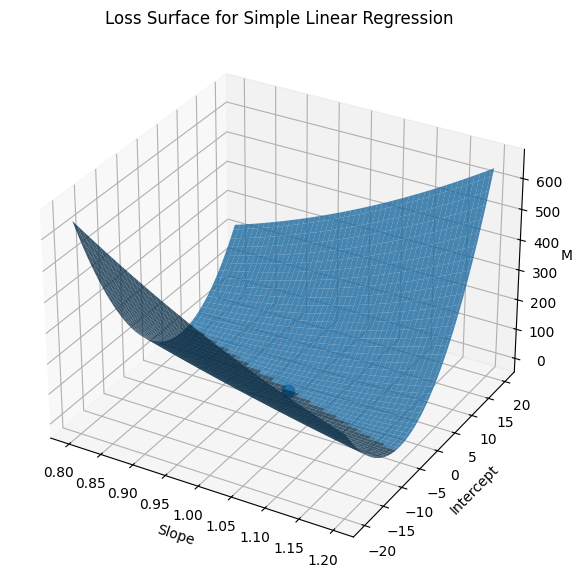

In [7]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(S, B, Loss, alpha=0.8)
ax.scatter(best_slope, best_intercept, best_loss, s=80)

ax.set_xlabel('Slope')
ax.set_ylabel('Intercept')
ax.set_zlabel('MSE')
ax.set_title('Loss Surface for Simple Linear Regression')

plt.show()

The x and y axes represent the slope and intercept of the possible regression line. The z axis shows the MSE, which measures the error from each possible combination of slope and intercept. The minimum point on the surface of the graph is the smallest MSE, which is the best fitting line for the data. If I had used MAE, the graph would look way less smooth and much sharper.

Part 4: Simple Linear Regression

Now you build the actual model. You must do this in two steps: manually first, then with sklearn. The numbers must match.

4a: Manual Implementation

Implement the following helper functions exactly as shown in lecture:

def standard_units(x): return (x - np.mean(x)) / np.std(x)

def correlation(x, y): return np.mean(standard_units(x) * standard_units(y))

def slope(x, y): return correlation(x, y) * np.std(y) / np.std(x)

def intercept(x, y): return np.mean(y) - slope(x, y) * np.mean(x)
Compute and print your slope and intercept. Then write out your model equation explicitly:

predicted [target] = [intercept] + [slope] * [feature]
Interpret both the slope and intercept in plain English using the actual variable names from your dataset. Generic interpretations like "b is the slope" will not receive credit.

In [8]:
#part 4a

m = slope(x, y)
b = intercept(x, y)

print("Slope:", m)
print("Intercept:", b)

print(f"predicted Close_NoSplits = {b} + {m} * Open_NoSplits")

Slope: 1.0015503248376885
Intercept: -0.03044462796699321
predicted Close_NoSplits = -0.03044462796699321 + 1.0015503248376885 * Open_NoSplits


My slope is 1.00155. This means that for every 1 dollar increase in opening price, the closing price increases for about 1.00155 on average.

-0.03044 is the intercept. This means that when the opening price is 0, the model predicts the closing price would be approximately -0.03044 dollars.

4b: Sklearn Verification

Fit the same model using sklearn and verify your parameters match:

from sklearn.linear_model import LinearRegression

model = LinearRegression() model.fit(df[['feature']], df['target'])

print(model.intercept_) print(model.coef_)
You must explicitly confirm that your manual slope and intercept match sklearn's output. If they do not match, you must debug and explain why.

4c: Visualization

You must produce a scatter plot of your feature versus your target with the regression line overlaid. Your plot must include:

A meaningful title
Labeled axes using your actual variable names
Both the data points and the fitted line clearly visible
Write 3 to 5 sentences interpreting what the line represents. Does it fit well? Where does it miss? Are there regions where the model is consistently wrong?

In [9]:
#part 4b

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(df[['Open_NoSplits']], df['Close_NoSplits'])

print(model.intercept_)
print(model.coef_)

-0.030444627966975446
[1.00155032]


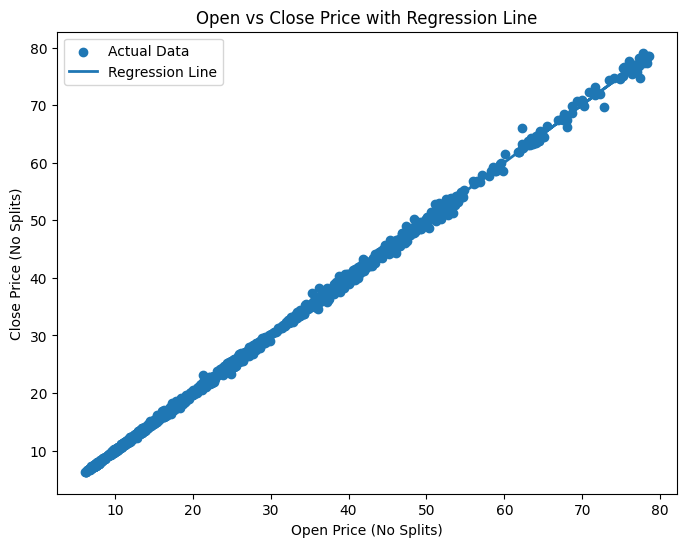

In [10]:
#part 4c

y_pred = b + m * x

plt.figure(figsize=(8,6))

plt.scatter(x, y, label='Actual Data')

plt.plot(x, y_pred, linewidth=2, label='Regression Line')

plt.xlabel('Open Price (No Splits)')
plt.ylabel('Close Price (No Splits)')
plt.title('Open vs Close Price with Regression Line')

plt.legend()
plt.show()

Part 5: Model Evaluation

5a: Error Comparison

Compute MSE and RMSE for your linear model and compare them directly to your constant model baseline from Part 2.

You must produce a comparison table.

Write 2 to 3 sentences answering: did your feature provide useful predictive information? How do you know?

In [11]:
#part 5a

df['pred_linear'] = b + m * df['Open_NoSplits']

df['error_linear'] = df['Close_NoSplits'] - df['pred_linear']
df['squared_error_linear'] = df['error_linear'] ** 2

mse_linear = df['squared_error_linear'].mean()
rmse_linear = mse_linear ** 0.5

print("Linear Model MSE:", mse_linear)
print("Linear Model RMSE:", rmse_linear)

Linear Model MSE: 0.13758109383978998
Linear Model RMSE: 0.37091925514832735


In [12]:
comparison = pd.DataFrame({
    'Model': ['Constant Model', 'Linear Model'],
    'MSE': [mse_constant, mse_linear],
    'RMSE': [rmse_constant, rmse_linear]
})

comparison

,Model,MSE,RMSE
0,Constant Model,226.506075,15.050119
1,Linear Model,0.137581,0.370919


The linear model has a much lower RMSE compared to the constant model, showing that it has provides accurate predictions of the closing price. Because the linear model reduces the error, it is a more effective model for this.

5b: R-Squared

Compute R-squared for your linear model:

r2 = np.var(df['pred_linear']) / np.var(df['target'])
Write 3 to 5 sentences interpreting your R-squared value. Your interpretation must answer:

What percentage of variation in your target does your model explain?
Is that a strong or weak result for your domain?
What does the remaining unexplained variation tell you about your model?

In [13]:
#part 5b
r2 = np.var(df['pred_linear']) / np.var(df['Close_NoSplits'])
print("R-squared:", r2)

R-squared: 0.9993925942438392


The R squared value resulted in an almost perfect fit and explains approximately 99.9% of variation in the closing price. This indicates that opening price has a direct correlation to closing price and can be a very powerful predictor. A value of 0.999 sugggests that they have a nearly perfect linear relationship. The unaccounted/unexplained variation of 0.00061 could be explained by noise captured by the model.

5c: Actual vs. Predicted Plot

Create a scatter plot of actual values on the x-axis against predicted values on the y-axis. Draw the diagonal reference line where actual equals predicted.

Write 3 to 5 sentences interpreting this plot. Points on the diagonal represent perfect predictions. What do points above or below the line tell you? Is your model systematically over or under predicting in any region?

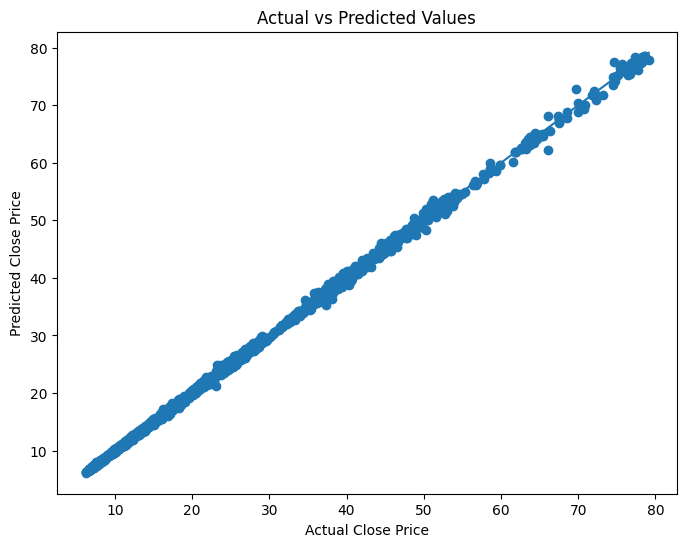

In [14]:
#part 5c
plt.figure(figsize=(8,6))
plt.scatter(df['Close_NoSplits'], df['pred_linear'])

# Diagonal reference line (perfect predictions)
min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])

# Labels
plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")
plt.title("Actual vs Predicted Values")

plt.show()


The points on this graph that are above the prediction line indicate there is an over estimation in our predicted close price, whilst the opposite means that there was an under estimation in our predictive closing price. Our model is systematically predicting very accurately from 0-50 closing price, and afterwards becomes less accurate but not necessarily innacurate or mostly over or under estimating.

Part 6: Residual Analysis

Residuals are the errors your model makes. Analyzing them tells you whether your model is capturing the full structure of your data or missing something important.

Compute your residuals and generate a residual plot.

For your written interpretation, answer all of the following in 4 to 6 full sentences:

What question are you answering with this plot?
Are the residuals randomly scattered around zero, or do you see a pattern?
If you see a pattern, what does that tell you about your model?
Are there any outliers in the residuals? What might explain them?
Does this plot change your confidence in the model? Why or why not?
Important: A residual plot that shows a clear curve or funnel shape means your linear model is missing structure in the data. That is not failure. That is a finding. Name it and explain it.

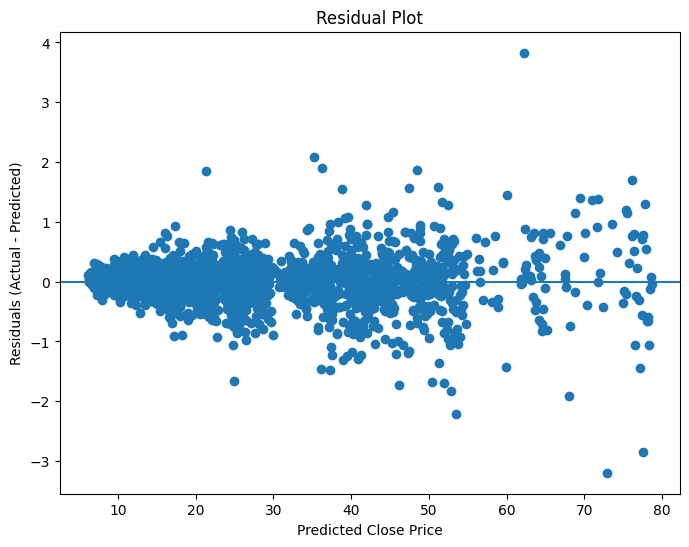

In [15]:
#part 6
residuals = y - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals)

plt.axhline(0)

plt.xlabel('Predicted Close Price')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot')

plt.show()

This residual plot answers how accurate and if we are under or over estimating in our prediction. From Predicted closing price 10-30 they are all very close to 0 but beyond that it's variance increases and becomes more spaced out and farther from 0 but is still mostly random. This shows that the model is more accurate when the predicted closing price is low, but as it gets higher it becomes less accurate. There does seem to be a few outliers but it can be explained by market fluctuations. Overall this plot increased our confidence because the errors are small and randomly distributed.

In [16]:
df1 = df.copy()

for col in ['Open_NoSplits', 'Close_NoSplits']:
    df1[col] = df1[col].replace(r'[\$,]', '', regex=True).astype(float)

df1['Prev_Close'] = df1['Close_NoSplits'].shift(1)

df1 = df1.dropna(subset=['Open_NoSplits', 'Prev_Close', 'Close_NoSplits'])

Part 7: Multiple Linear Regression (Intro)

Now try adding a second feature to your model. This is an introduction, not a full analysis. The goal is to test whether a second variable provides new information that improves your predictions.

You must:

Select a second feature from your dataset and justify the choice in 1 to 2 sentences
Fit a multiple linear regression model using sklearn with both features
Compute MSE and RMSE for the new model
Add the result to your comparison table from Part 5a
Interpret whether the second feature helped and why or why not
Important: More features do not automatically mean a better model. They only help if they provide new information. Your job is to test this, not assume it.

Write 3 to 5 sentences summarizing your findings from this section. Did the second feature improve your model? By how much? Would you keep it in a final model?

In [17]:
#part 7

print("--Before--")
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")
print("Linear Model MSE:", mse_linear)
print("Linear Model RMSE:", rmse_linear)
print("--After--")
model1 = LinearRegression()
model1.fit(df1[['Open_NoSplits', 'Prev_Close']], df1['Close_NoSplits'])
print(f"Coefficients: {model1.coef_}")
print(f"Intercept: {model1.intercept_}")

df1['pred_linear'] = model1.intercept_ + model1.coef_[0] * df1['Open_NoSplits'] + model1.coef_[1] * df1['Prev_Close']

df1['error_linear'] = df1['Close_NoSplits'] - df1['pred_linear']
df1['squared_error_linear'] = df1['error_linear'] ** 2

mse_linear1 = df1['squared_error_linear'].mean()
rmse_linear1 = mse_linear1 ** 0.5

print("Linear Model MSE:", mse_linear1)
print("Linear Model RMSE:", rmse_linear1)


constant_prediction = df1['Close_NoSplits'].mean() 
df1['pred_constant'] = constant_prediction 
df1['error'] = df1['Close_NoSplits'] - df1['pred_constant']
df1['squared_error'] = df1['error'] ** 2

mse_constant1 = df1['squared_error'].mean()
rmse_constant1 = mse_constant1 ** 0.5

comparison1 = pd.DataFrame({
    'Model': ['Constant Model', 'Linear Model'],
    'MSE': [mse_constant1, mse_linear1],
    'RMSE': [rmse_constant1, rmse_linear1]
})
print("--Before--")
print(comparison) #from part 5a
print("--After--")
print(comparison1)
print("--Difference--")
print("MSE: ", mse_linear1 - mse_linear)
print("RMSE: ", rmse_linear1 - rmse_linear)

--Before--
Coefficients: [1.00155032]
Intercept: -0.030444627966975446
Linear Model MSE: 0.13758109383978998
Linear Model RMSE: 0.37091925514832735
--After--
Coefficients: [0.65033547 0.35031757]
Intercept: -0.01982895618521141
Linear Model MSE: 0.08823531269057906
Linear Model RMSE: 0.2970442941559037
--Before--
            Model         MSE       RMSE
0  Constant Model  226.506075  15.050119
1    Linear Model    0.137581   0.370919
--After--
            Model         MSE       RMSE
0  Constant Model  225.962635  15.032054
1    Linear Model    0.088235   0.297044
--Difference--
MSE:  -0.04934578114921091
RMSE:  -0.07387496099242363


We chose to add the previous closing price as a second feature for our model because the stock pricing is highly correlated to the previous day. It helps capture the momentum of the stock in the short term.

Adding a second feature was beneficial as it decreased our MSE and RMSE which means a higher accuracy. To be exact, the MSE improved by 0.049 and RMSE improved by 0.074. This improvement is big enough for us to say that we should keep it in our model.


Part 8: Reflection

Write two paragraphs.

Paragraph 1: Look back at your Phase 2 EDA. What did your visualizations predict about which features would be useful? Was your Phase 2 analysis right? If your model performed differently than you expected, explain why you think that happened.

Paragraph 2: Based on your residual plot and your R-squared value, what does your model still get wrong? What would you try next to improve it? What additional data, features, or transformations might help?

A reflection that says "my model worked well" with no evidence of critical thinking will not receive full credit. The best reflections identify specific weaknesses and propose concrete next steps.

In Phase 2 the visualizations suggested that opening price is a strong predictor of closing price because the data represented a strong linear relationship between the two. The visualization was correct because when we created a prediction model we received a high r squared and a low RMSE which means that opening price is a useful feature. When we added the previous day's closing price it also improved the model because it captured short term price change and helped take into account of closing price trends between days.

The residual plot shows that most errors are small and randomly scattered, but it still misses slight variations in price that are not explained by our features. Even with a high r squared, the remaining error suggests that outside factors are not captured. There is also a chance for outliers caused by unusual trading habits in a day. To improve the model by adding features for volume and previous closing price.